# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [3]:
import os
import sys
import argparse
import pickle
from datetime import datetime

import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import min_weight_full_bipartite_matching

from drvi.utils.plotting import cmap as drvi_cmap
from drvi.utils.metrics import DiscreteDisentanglementBenchmark
from drvi_notebooks.utils.data.adata_plot_pp import make_balanced_subsample
from drvi_notebooks.utils.data.data_configs import get_data_info
from drvi_notebooks.utils.run_info import get_run_info_for_dataset
from drvi_notebooks.utils.method_info import pretify_method_name, methods_general_order
from drvi_notebooks.utils.latent import set_optimal_ordering

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import mplscience

sc.set_figure_params(vector_friendly=True, dpi_save=300)
mplscience.available_styles()
mplscience.set_style()

['default', 'despine']


# Config

In [6]:
parser = argparse.ArgumentParser()

parser.add_argument('--run-name', type=str)
parser.add_argument('--plot', action='store_true', help='Plot some details.')

interactive = False
if hasattr(sys, 'ps1'):
    args = parser.parse_args("--run-name immune_hvg".split(" "))
    # args = parser.parse_args("--run-name pbmc_covid_hvg".split(" "))
    # args = parser.parse_args("--run-name hlca".split(" "))
    # args = parser.parse_args("--run-name hlca_drs".split(" "))
    # args = parser.parse_args("--run-name norman_hvg".split(" "))
    interactive = True
else:
    args = parser.parse_args()
print(args)

Namespace(run_name='immune_hvg', plot=False)


In [7]:
try:
    cwd = str(Path(__vsc_ipynb_file__).parent)
except:
    cwd = Path.cwd()
cwd

PosixPath('/ictstr01/home/icb/amirali.moinfar/projects/drvi_reproducibility_public/drvi_notebooks/evaluation')

In [8]:
# proj_dir = Path(cwd).parent.parent
proj_dir = Path('~/projects/drvi_reproducibility_public').expanduser()
proj_dir

PosixPath('/home/icb/amirali.moinfar/projects/drvi_reproducibility_public')

In [9]:
logs_dir = Path('~/workspace/train_logs').expanduser()
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

In [10]:
save_dir = proj_dir / 'plots' / 'disentanglement'
save_dir.mkdir(parents=True, exist_ok=True)
save_dir

PosixPath('/home/icb/amirali.moinfar/projects/drvi_reproducibility_public/plots/disentanglement')

In [11]:
run_name = args.run_name
real_run_name = run_name
if run_name == 'zebrafish_hvg_128':
    real_run_name = 'zebrafish_hvg'
if run_name in ['michigan_immune_param_optimization']:
    real_run_name = 'immune_hvg'
if run_name.endswith("_ablation"):
    real_run_name = run_name[:-len("_ablation")]
if run_name.endswith("_drs"):
    real_run_name = run_name[:-len("_drs")]
if run_name in ['immune_all_hbw_ablation']:
    real_run_name = 'immune_all'
run_version = '4.3'
run_path = os.path.expanduser('~/workspace/train_logs/models')

data_info = get_data_info(real_run_name, run_version)
wandb_address = data_info['wandb_address']
col_mapping = data_info['col_mapping']
plot_columns = data_info['plot_columns']
pp_function = data_info['pp_function']
data_path = data_info['data_path']
var_gene_groups = data_info['var_gene_groups']
cell_type_key = data_info['cell_type_key']
exp_plot_pp = data_info['exp_plot_pp']
control_treatment_key = data_info['control_treatment_key']
condition_key = data_info['condition_key']
split_key = data_info['split_key']
ground_truth_one_hot_key = data_info['ground_truth_one_hot_key']

In [12]:
cat_10_pallete = sc.plotting.palettes.vega_10_scanpy
cat_20_pallete = sc.plotting.palettes.vega_20_scanpy
wong_pallete = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000",
]
cat_100_pallete = sc.plotting.palettes.godsnot_102

In [13]:
# Sometimes rapid_single_cell UMAP creates some outliers.
def trim_umap(embed, old_key='X_umap', new_key='X_umap', threshold=1e-5):
    x_min, x_max = np.quantile(embed.obsm[old_key][:, 0], (threshold, 1-threshold))
    x_min, x_max = float(x_min), float(x_max)
    y_min, y_max = np.quantile(embed.obsm[old_key][:, 1], (threshold, 1-threshold))
    y_min, y_max = float(y_min), float(y_max)
    embed.obsm[new_key] = np.vstack([embed.obsm[old_key][:, 0].clip(x_min, x_max), embed.obsm[old_key][:, 1].clip(y_min, y_max)]).T

In [14]:
METRICS = ['SMI-disc', 'SPN', 'ASC']
AGGREGATION_METHODS = ['LMS', 'MSAS', 'MSGS']

## Runs to load

In [15]:
run_info = get_run_info_for_dataset(run_name)
RUNS_TO_LOAD = run_info.run_dirs
scatter_point_size = run_info.scatter_point_size
adata_to_transfer_obs = run_info.adata_to_transfer_obs
if adata_to_transfer_obs is not None:
    adata_to_transfer_obs = sc.read(adata_to_transfer_obs)

for k,v in RUNS_TO_LOAD.items():
    if not os.path.exists(v):
        raise ValueError(f"{v} does not exists.")

In [16]:
RUNS_TO_LOAD

{'DRVI': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-115959-272081'),
 'DRVI-IK': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-120129-576776'),
 'scVI': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/scvi_20240430-114522-508980'),
 'scVI-PCA': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/scvi-pca_20250305-183500-629296'),
 'scVI-ICA': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/scvi-ica_20250305-182349-410740'),
 'PCA': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/clear-meadow-12'),
 'ICA': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/apricot-feather-12'),
 'MOFA': PosixPath('/home/icb/amirali.moinfar/workspace/train_logs/models/robust-universe-14'),
 'TCVAE-opt': PosixPath('/home/icb/amirali.moinfar/io/michigan/michigan_embed_immune_hvg_32_run_opt_tcvae_final.h5ad'),
 'MICHIGAN-opt': PosixPath('/home/icb/amirali.moinfar

In [17]:
embeds = {}
random_order = None
for method_name, run_path in RUNS_TO_LOAD.items():
    print(method_name)
    if str(run_path).endswith(".h5ad"):
        embed = sc.read(run_path)
    else:
        if (run_path / 'latent_sorted.h5ad').exists():
            embed = sc.read(run_path / 'latent_sorted.h5ad')
        else:
            embed = sc.read(run_path / 'latent.h5ad')
    if embed.n_vars > 512:
        embed = embed[:, np.abs(embed.X).max(axis=0) > 0.1].copy()
    # trim_umap(embed, threshold=1e-3)
    pp_function(embed)
    set_optimal_ordering(embed, key_added='optimal_var_order', metric='euclidean+')
    if random_order is None:
        random_order = embed.obs.sample(frac=1.).index
    embed = embed[random_order].copy()
    embeds[method_name] = embed
    if adata_to_transfer_obs is not None:
        for col in adata_to_transfer_obs.obs.columns:
            if col not in embed.obs.columns:
                embed.obs[col] = adata_to_transfer_obs.obs[col]
    if ground_truth_one_hot_key is not None:
        embed.obsm[ground_truth_one_hot_key] = sc.read_h5ad(data_path, backed='r')[embed.obs.index].obsm[ground_truth_one_hot_key]

DRVI
DRVI-IK
scVI
scVI-PCA
scVI-ICA
PCA
ICA
MOFA
TCVAE-opt
MICHIGAN-opt
DRVI-CVAE
LIGER
scETM


In [18]:
evals = {}
if ground_truth_one_hot_key is not None:
    col = ground_truth_one_hot_key
else:
    col = cell_type_key
version = DiscreteDisentanglementBenchmark.version

for method_name, embed in embeds.items():
    if str(RUNS_TO_LOAD[method_name]).endswith('.h5ad'):
        filename = Path(str(RUNS_TO_LOAD[method_name])[:-len('.h5ad')] + f'_DR_benchmark_on_{col}_{version}.pkl')
    else:
        filename = RUNS_TO_LOAD[method_name] / f'DR_benchmark_on_{col}_{version}.pkl'

    print(filename)

    if ground_truth_one_hot_key is not None:
        discrete_target, one_hot_target = None, embed.obsm[col]
    else:
        discrete_target, one_hot_target = embed.obs[col], None
    
    if not filename.exists():
        print(f"Calculating disentanglement for {method_name} on {col}")
        filename.touch()
        start_time = datetime.now()
        benchmark = DiscreteDisentanglementBenchmark(
            embed.X, discrete_target=discrete_target, one_hot_target=one_hot_target,
            metrics=METRICS, aggregation_methods=AGGREGATION_METHODS,
        )
        benchmark.evaluate()
        benchmark.save(filename)
        print(f"Time taken: {(datetime.now() - start_time).total_seconds():.2f} seconds")

    benchmark = DiscreteDisentanglementBenchmark.load(filename, embed.X, discrete_target=discrete_target, one_hot_target=one_hot_target,
                                                      metrics=METRICS, aggregation_methods=AGGREGATION_METHODS)
    if not benchmark.is_complete():
        print(f"Completing disentanglement scores for {method_name} on {col}")
        start_time = datetime.now()
        benchmark.evaluate()
        benchmark.save(filename)
        print(f"Time taken: {(datetime.now() - start_time).total_seconds():.2f} seconds")

    print(f"Loading disentanglement results for {method_name} on {col}")
    benchmark = DiscreteDisentanglementBenchmark.load(filename, embed.X, discrete_target=discrete_target, one_hot_target=one_hot_target,
                                                      metrics=METRICS, aggregation_methods=AGGREGATION_METHODS)
    evals[method_name] = benchmark

/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-115959-272081/DR_benchmark_on_final_annotation_v2.pkl
Loading disentanglement results for DRVI on final_annotation
/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-120129-576776/DR_benchmark_on_final_annotation_v2.pkl
Loading disentanglement results for DRVI-IK on final_annotation
/home/icb/amirali.moinfar/workspace/train_logs/models/scvi_20240430-114522-508980/DR_benchmark_on_final_annotation_v2.pkl
Loading disentanglement results for scVI on final_annotation
/home/icb/amirali.moinfar/workspace/train_logs/models/scvi-pca_20250305-183500-629296/DR_benchmark_on_final_annotation_v2.pkl
Loading disentanglement results for scVI-PCA on final_annotation
/home/icb/amirali.moinfar/workspace/train_logs/models/scvi-ica_20250305-182349-410740/DR_benchmark_on_final_annotation_v2.pkl
Loading disentanglement results for scVI-ICA on final_annotation
/home/icb/amirali.moinfar/workspace/train_logs/models/clear-meadow

In [19]:
comparative_df = pd.DataFrame([
    {'Method': pretify_method_name(method_name), **evals[method_name].get_results()}
    for method_name in embeds.keys()
])
comparative_df.to_csv(proj_dir / 'results' / f'eval_disentanglement_{run_name}_all.csv')
print(comparative_df)

      Method  LMS-SMI-disc   LMS-SPN   LMS-ASC  MSAS-SMI-disc  MSAS-SPN  \
0       DRVI      0.680603  0.656997  0.302808       0.695015  0.687131   
1    DRVI-AP      0.503272  0.412157  0.283210       0.516340  0.425555   
2       scVI      0.536190  0.467460  0.267417       0.613928  0.521524   
3   scVI-PCA      0.280433  0.197560  0.223189       0.422439  0.288156   
4   scVI-ICA      0.363249  0.325267  0.227695       0.466467  0.399666   
5        PCA      0.539468  0.467818  0.281113       0.585575  0.507922   
6        ICA      0.658144  0.629609  0.259860       0.673333  0.651179   
7       MOFA      0.537809  0.464211  0.288121       0.595777  0.512028   
8    B-TCVAE      0.439059  0.332879  0.287738       0.485790  0.364033   
9   MICHIGAN      0.150053  0.080780  0.174226       0.155347  0.084830   
10      CVAE      0.488735  0.422660  0.270220       0.579948  0.503596   
11     LIGER      0.589463  0.657591  0.308891       0.599346  0.657591   
12     scETM      0.49460

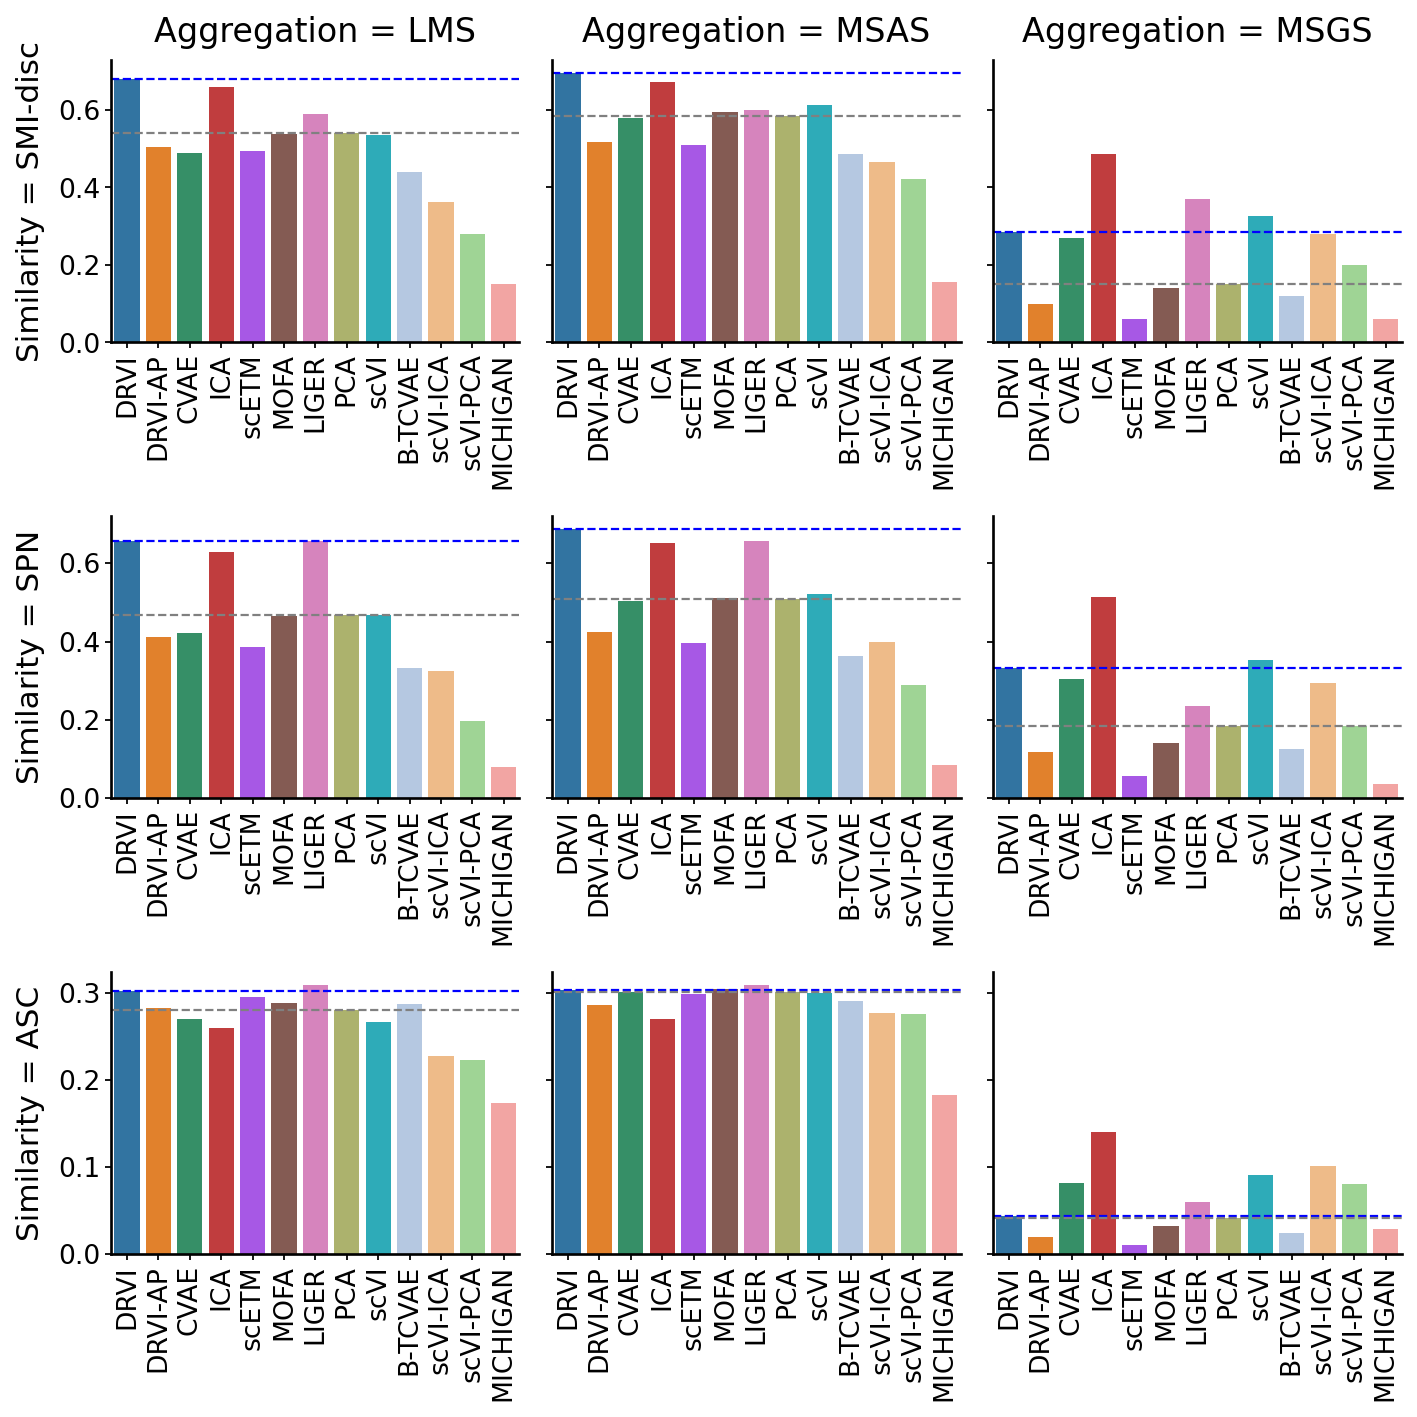

In [20]:
df = comparative_df

df_melted = df.melt(id_vars=['Method'], var_name='metric', value_name='score')
df_melted[['aggregation_method', 'similarity_function']] = df_melted['metric'].str.split('-', 1, expand=True)

method_order = [m for m in methods_general_order if m in comparative_df['Method'].unique().tolist()]
method_order += [m for m in comparative_df['Method'].unique().tolist() if m not in method_order]
method_palette = dict(zip(method_order, cat_20_pallete))

# Create a 3x3 grid of plots
fig, axes = plt.subplots(len(METRICS), len(AGGREGATION_METHODS), figsize=(3 * len(AGGREGATION_METHODS), 3 * len(METRICS)), sharey='row')

for i, similarity_function in enumerate(METRICS):
    for j, aggregation_method in enumerate(AGGREGATION_METHODS):
        ax = axes[i, j]
        # Filter the data for the current metric type and name
        current_data = df_melted[(df_melted['aggregation_method'] == aggregation_method) & (df_melted['similarity_function'] == similarity_function)]
        
        # Create the bar plot
        sns.barplot(
            data=current_data,
            x='Method', y='score', hue='Method',
            palette=method_palette, hue_order=method_order, order=method_order,
            ax=ax
        )
        
        # Set titles and labels
        if i == 0:
            ax.set_title(f'Aggregation = {aggregation_method}')
        # ax.set_xlabel('Method')
        ax.set_xlabel('')
        ax.set_ylabel(f'Similarity = {similarity_function}')
        ax.tick_params(axis='x', rotation=90)
        
        # Add horizontal lines for reference
        ax.grid(False)
        score_drvi = current_data[current_data['Method'] == 'DRVI'].iloc[0]['score']
        ax.axhline(y=score_drvi, linewidth=1., color='blue', linestyle='--')
        score_pca = current_data[current_data['Method'] == 'PCA'].iloc[0]['score']
        ax.axhline(y=score_pca, linewidth=1., color='grey', linestyle='--')

# Adjust layout
plt.tight_layout()
plt.savefig(save_dir / f"eval_disentanglement_{run_name}_all.pdf", bbox_inches='tight')
plt.show()

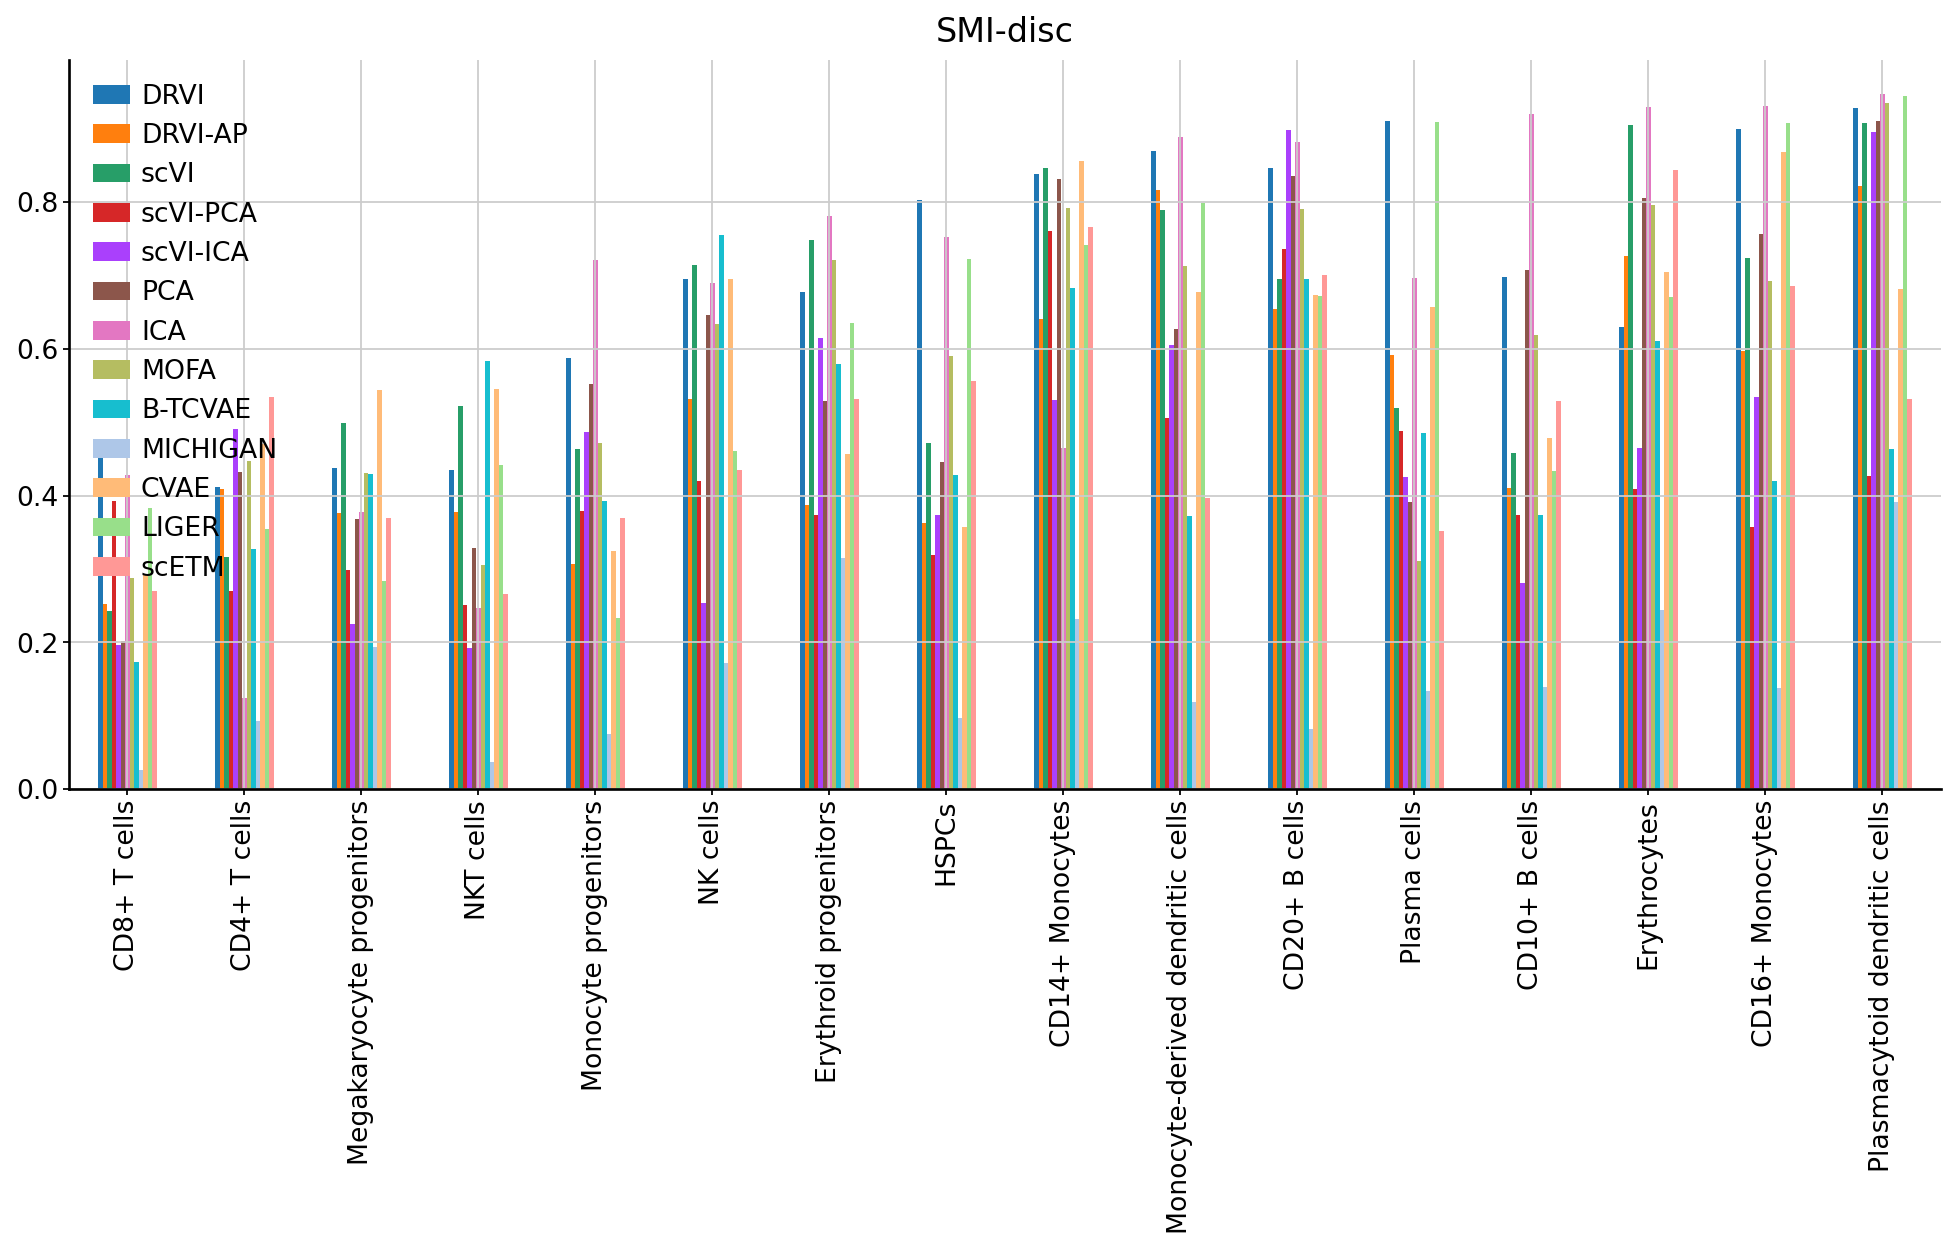

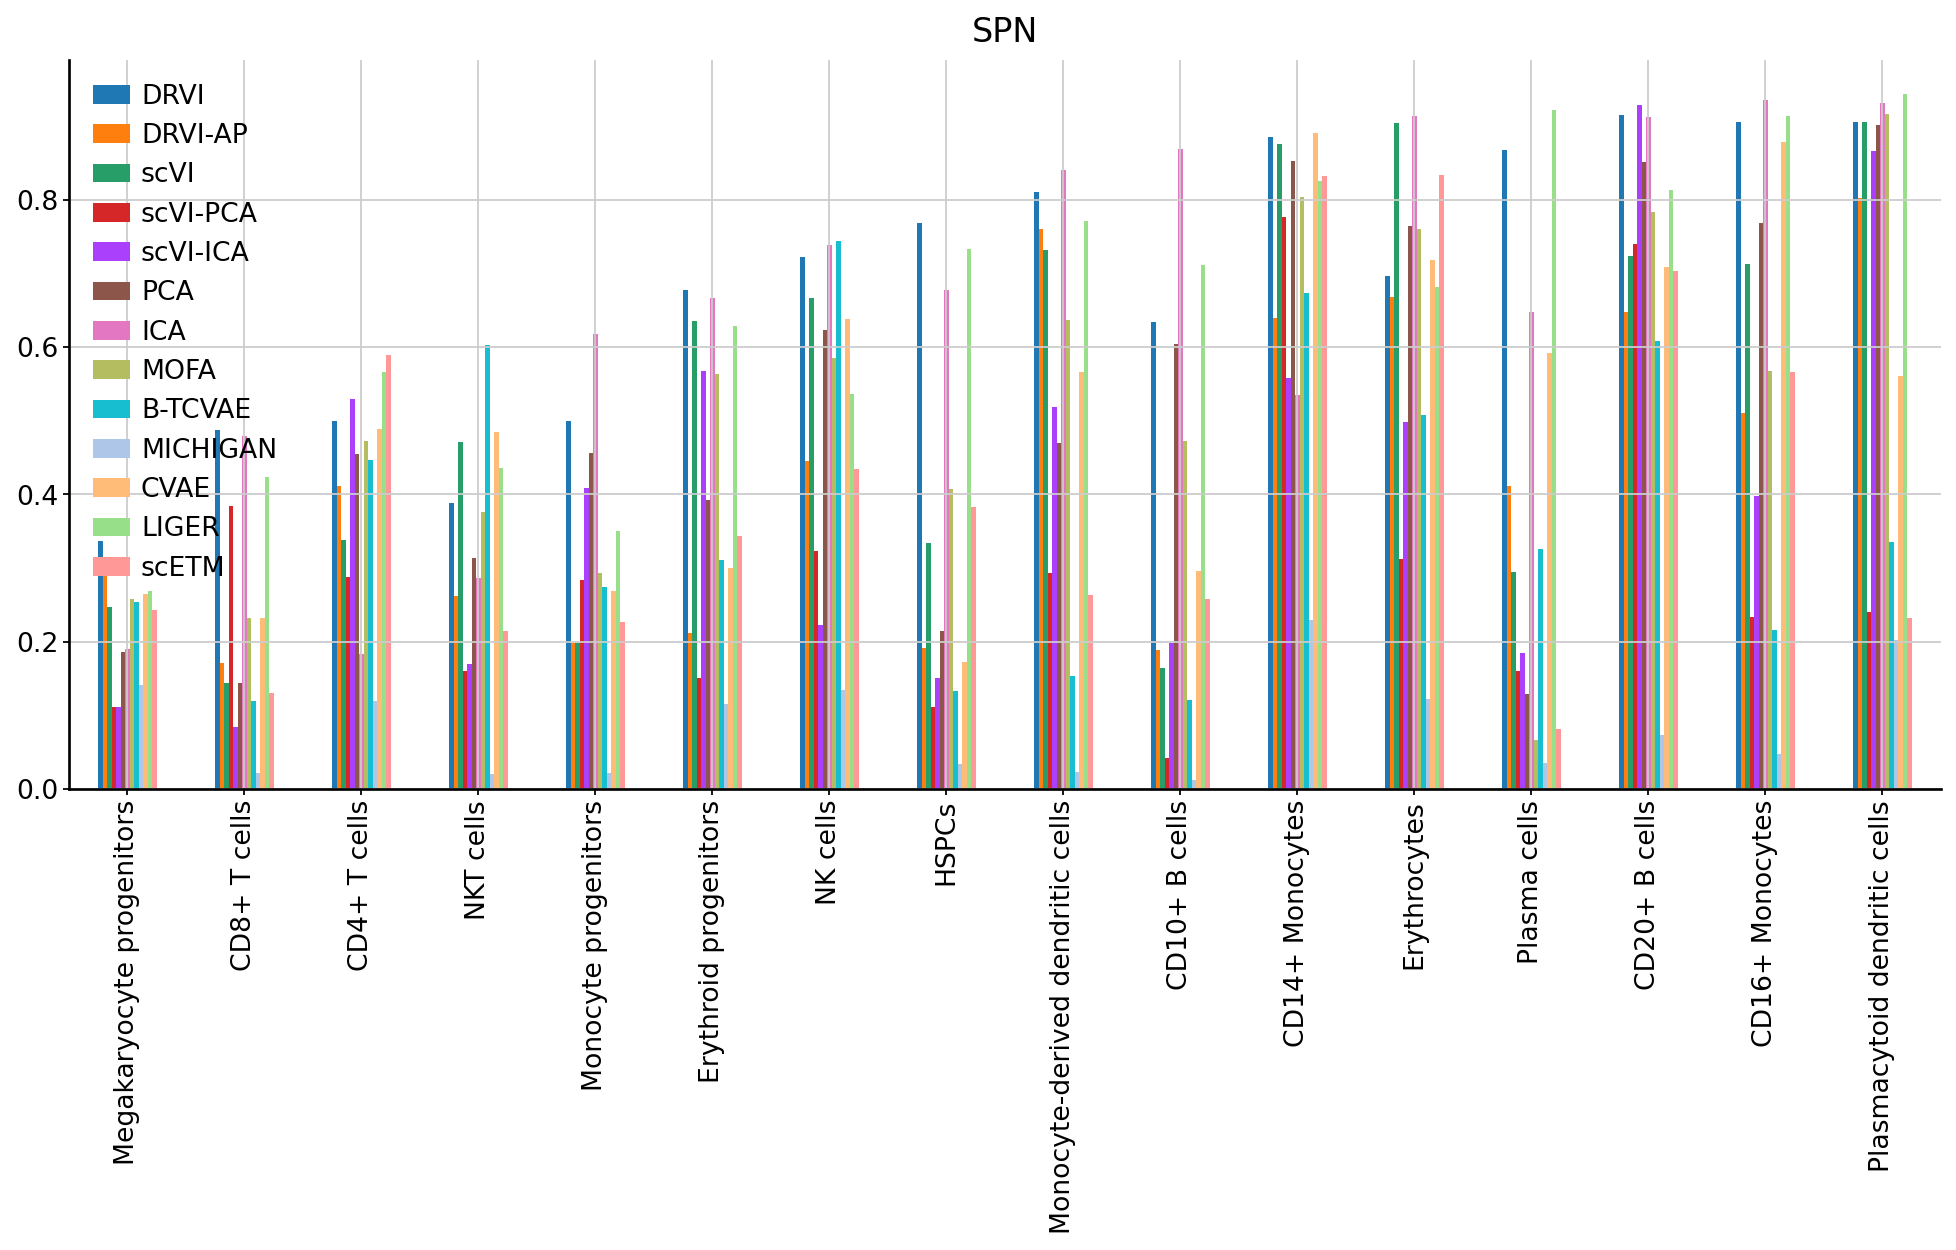

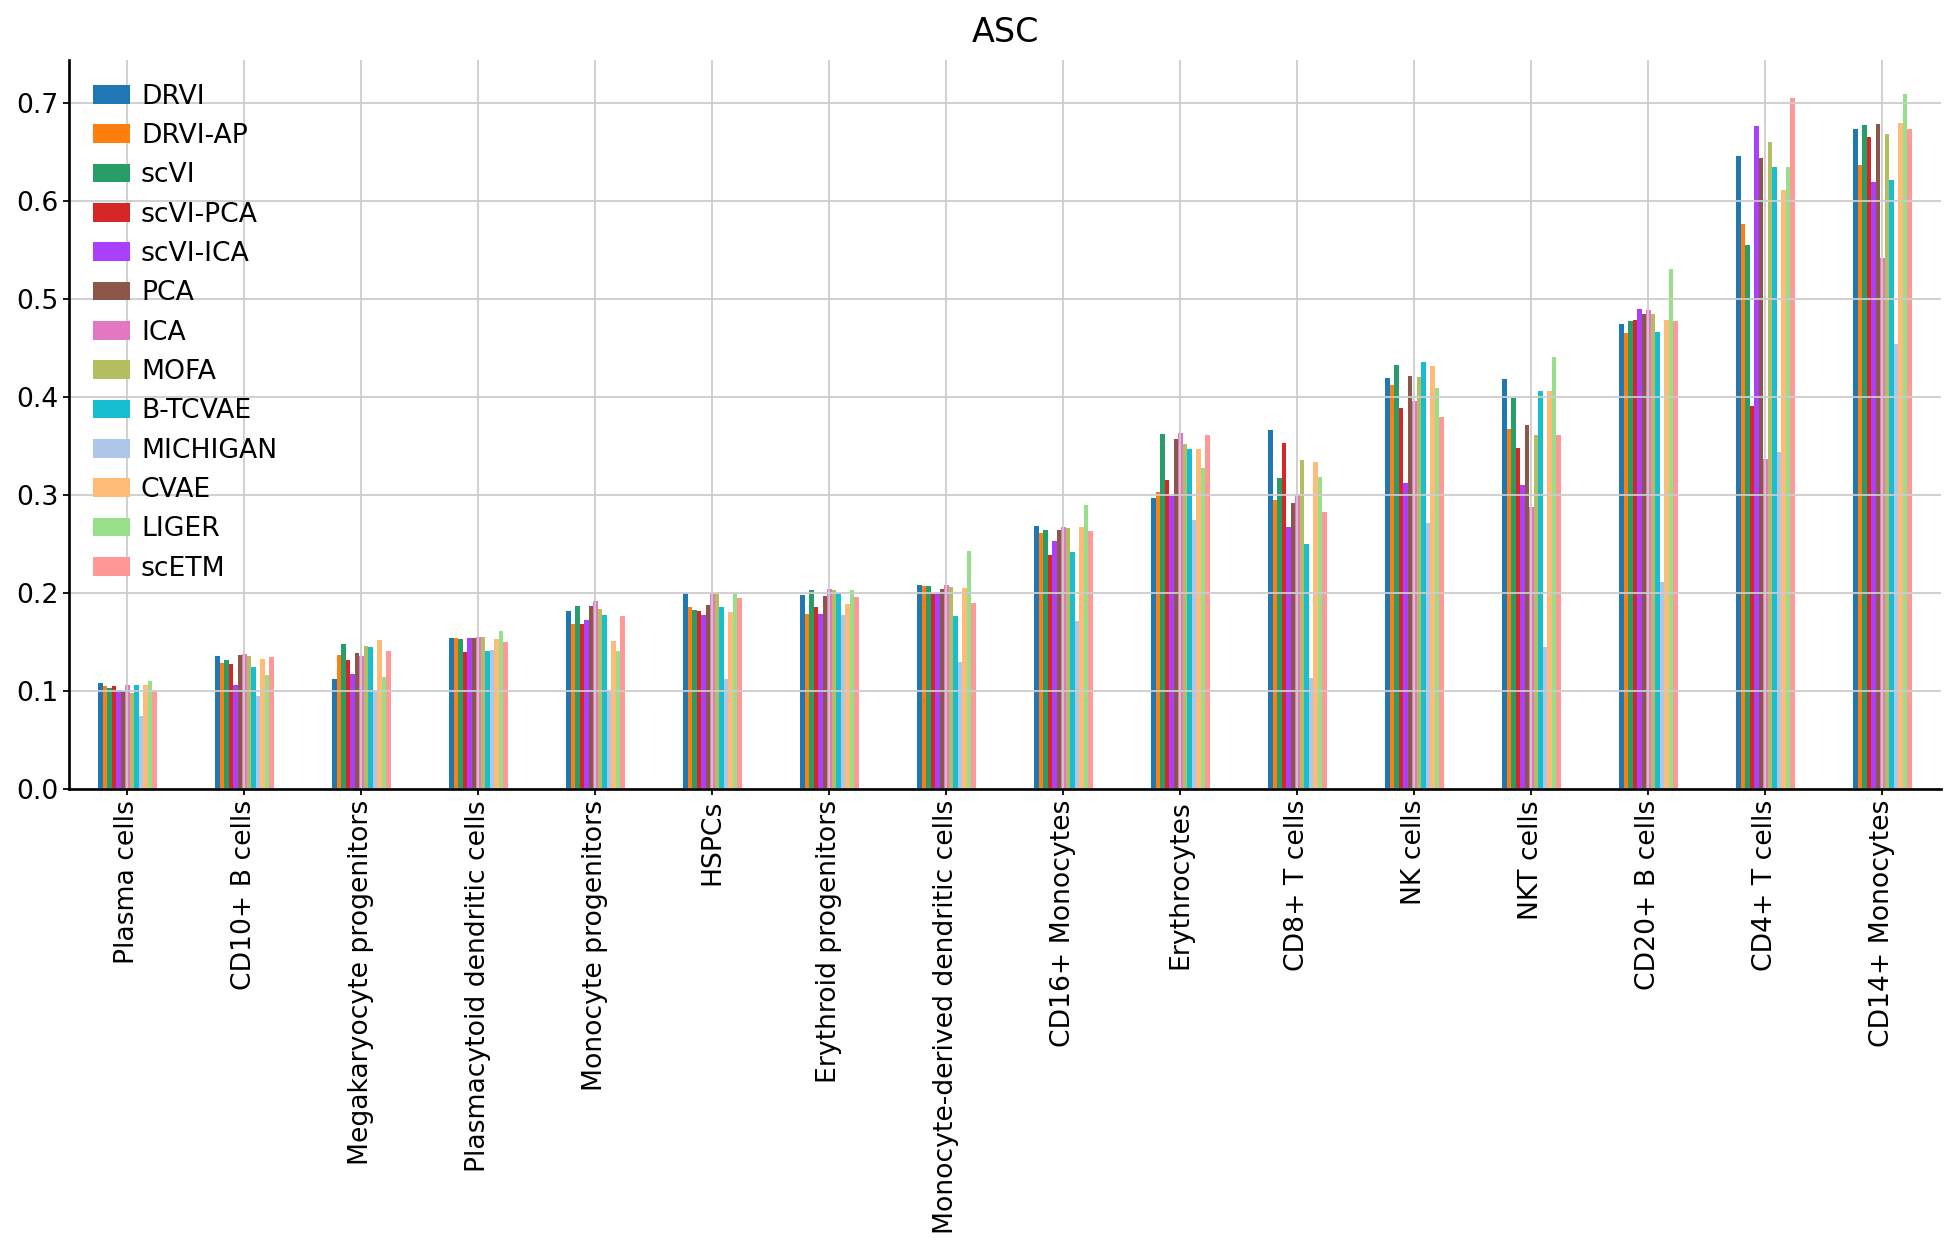

In [21]:
for metric_name in METRICS:
    comparative_df = pd.DataFrame({
        pretify_method_name(method_name): evals[method_name].get_results_details()[metric_name].max(axis=0)
        for method_name in embeds.keys()
    })
    comparative_df['max'] = comparative_df.max(axis=1)
    comparative_df.sort_values('max', ascending=True).drop(columns=['max']).plot.bar(title=metric_name, figsize=(15, 6))
    plt.show()

## Plotting

In [22]:
if not args.plot:
    exit()

In [23]:
(save_dir / 'heatmaps').mkdir(parents=True, exist_ok=True)

def sort_vars(embed, sim_matrix):
    vars = embed.var
    vars['van'] = ~ (np.abs(embed.X).max(axis=0, keepdims=True) > np.abs(embed.X).max() / 5).flatten()
    vars['van'] = np.logical_and(vars['van'], (sim_matrix.max(axis=1) < 0.1).values)
    sim_matrix = (sim_matrix + 0.1) * (~(vars['van'].values[:, np.newaxis]))
    vars['plot_order'] = np.hstack([sim_matrix, sim_matrix * 0.01 + 0.3]).argmax(axis=1).tolist()
    if 'title' not in vars.columns:
        vars['title'] = np.char.add('Dim ', (1 + np.arange(embed.n_vars)).astype(str))
        vars['order'] = np.arange(embed.n_vars)
    vars['not_interesting'] = np.logical_or(vars['van'], vars['plot_order']==sim_matrix.shape[1])
    vars = pd.concat([vars.query('~not_interesting').sort_values('plot_order'), vars.query('not_interesting').sort_values('order')])
    return vars

for method_name, run_path in RUNS_TO_LOAD.items():
    print(method_name)
    embed = embeds[method_name]
    sim_matrix = evals[method_name].get_results_details()['SMI-disc']
    for k in plot_columns:
        if embed.obs[k].dtype in [np.float32, np.float64]:
            continue
        print(k)
        filename = save_dir / f'eval_disentanglement_{run_name}_heatmap_{k}_{method_name}.pdf'
        if filename.exists():
            continue
        embed_balanced = make_balanced_subsample(embed, k)
        vars = sort_vars(embed_balanced, sim_matrix)
        g = sc.pl.heatmap(
            embed_balanced,
            vars['title'],
            k,
            gene_symbols='title',
            layer=None,
            figsize=(10, len(embed.obs[k].unique()) / 6),
            var_group_rotation=45,
            show_gene_labels=True,
            # dendrogram='+' not in col_mapping[k],
            vcenter=0, # vmin=-4, vmax=4,
            cmap=drvi_cmap.saturated_red_blue_cmap,
            show=False,
        )
        ax = g['heatmap_ax']
        g['groupby_ax'].set_ylabel('')
        ax.text(-0.3, 1., pretify_method_name(method_name), size=12, ha='left', weight='bold', color='black', rotation=0, transform=ax.transAxes)
        plt.savefig(filename, bbox_inches='tight')
        plt.show()

DRVI
batch
final_annotation
DRVI-IK
batch
final_annotation
scVI
batch
final_annotation
scVI-PCA
batch
final_annotation
scVI-ICA
batch
final_annotation
PCA
batch
final_annotation
ICA
batch
final_annotation
MOFA
batch
final_annotation
TCVAE-opt
batch
final_annotation
MICHIGAN-opt
batch
final_annotation
DRVI-CVAE
batch
final_annotation
LIGER
batch
final_annotation
scETM
batch
final_annotation


In [24]:
# Confusion like plot
METRICS_FOR_DETAILED_PLOT = ['SMI-disc', 'SPN']
column_order = None

(save_dir / 'details').mkdir(parents=True, exist_ok=True)
for i, metric_name in enumerate(METRICS_FOR_DETAILED_PLOT):
    if metric_name == 'SMI-disc':
        pretty_metric_name = 'SMI'
    else:
        pretty_metric_name = metric_name
    max_val = max(evals[method_name].get_results_details()[metric_name].values.max() for method_name in embeds.keys())
    for method_name, embed in embeds.items():
        filename = save_dir / 'details' / f'metric_heatmap_{run_name}_{metric_name}_{method_name}.pdf'
        if filename.exists():
            continue
        df = evals[method_name].get_results_details()[metric_name].copy()
        if column_order is None:
            column_order = df.columns.tolist()
        else:
            df = df[column_order].copy()
        if df.index[0].startswith('dim_'):
            if 'title' in embed.var:
                df.index = embed.var['title']
            else:
                df.index = 'Dim ' + df.index.astype(str).str.split('_').str[-1]
        
        row_ind, col_ind = min_weight_full_bipartite_matching(csr_matrix(-df.values - 1e-10))
        indices_order = np.argsort(col_ind)
        row_ind, col_ind = row_ind[indices_order], col_ind[indices_order]
        row_ind = list(row_ind) + list(set(range(df.shape[0])).difference(row_ind))
        col_ind = list(col_ind) + list(set(range(df.shape[1])).difference(col_ind))
        df = df.iloc[row_ind, col_ind]
        
        plt.figure(figsize=(df.shape[1] / 1.5, df.shape[0] / 2.6))
        ax = sns.heatmap(
            df,
            annot=True,
            fmt=".2f",
            cmap=drvi_cmap.saturated_just_sky_cmap,
            linewidths=0.,
            cbar=True,
            cbar_kws={
                'label': f'{pretty_metric_name} similarity values',
                'pad': 0.01, 'shrink': 0.25,
            },
            vmin=0.,
            vmax=max_val,
        )
        ax.grid(False)
        
        plt.title(f"Pairwise similarity {pretty_metric_name} for {method_name}")
        plt.xlabel("Cell Types")
        plt.ylabel("Dimensions")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        
        # Show the plot
        plt.tight_layout()
        plt.savefig(filename, bbox_inches='tight')
        plt.show()